In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150

df_raw = pd.read_csv('Ad_click_prediction_train (1).csv')
df = df_raw.copy()
print(df.shape)
df.head()


(28478, 15)


,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520.0,13787.0,4.0,NaN,10.0,Female,4.0,3.0,3.0,0.0,0.0
1,333291,2017-07-02 00:00,243253,C,105960.0,11085.0,5.0,NaN,8.0,Female,2.0,2.0,NaN,0.0,0.0
2,129781,2017-07-02 00:00,243253,C,359520.0,13787.0,4.0,NaN,8.0,Female,2.0,2.0,NaN,0.0,0.0
3,464848,2017-07-02 00:00,1097446,I,359520.0,13787.0,3.0,NaN,3.0,Male,3.0,3.0,2.0,1.0,0.0
4,90569,2017-07-02 00:01,663656,C,405490.0,60305.0,3.0,NaN,2.0,Male,2.0,3.0,2.0,1.0,0.0


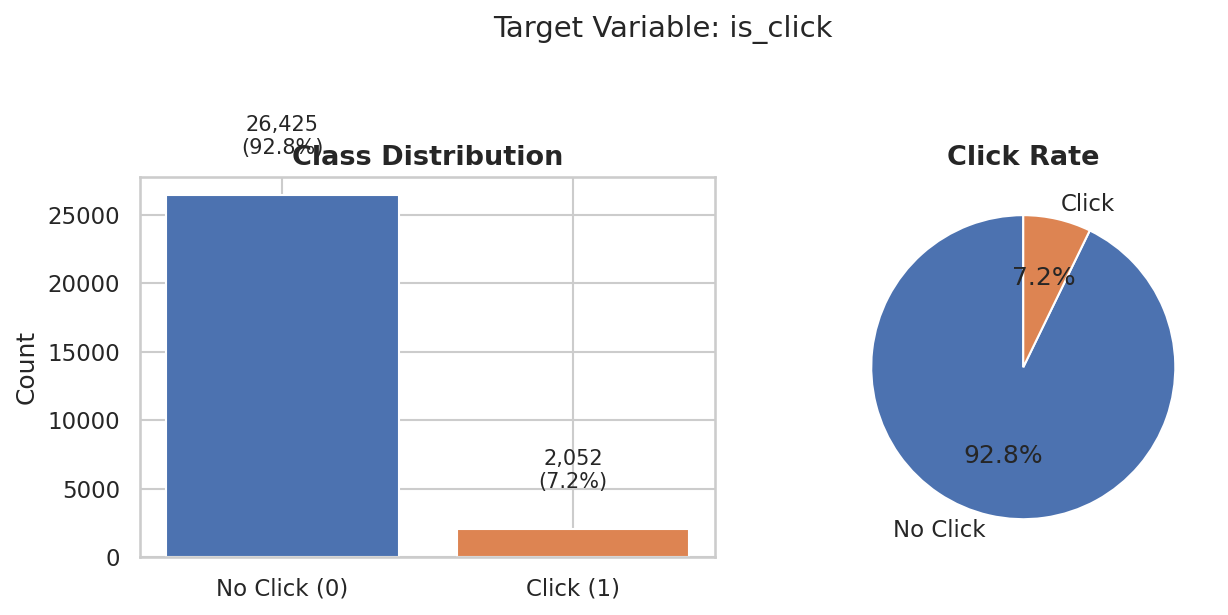

Click rate: 7.21%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Count plot
click_counts = df['is_click'].value_counts()
axes[0].bar(['No Click (0)', 'Click (1)'], click_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(click_counts.values):
    axes[0].text(i, v + 3000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(click_counts.values, labels=['No Click', 'Click'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Click Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: is_click', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Click rate: {click_counts[1]/len(df)*100:.2f}%")

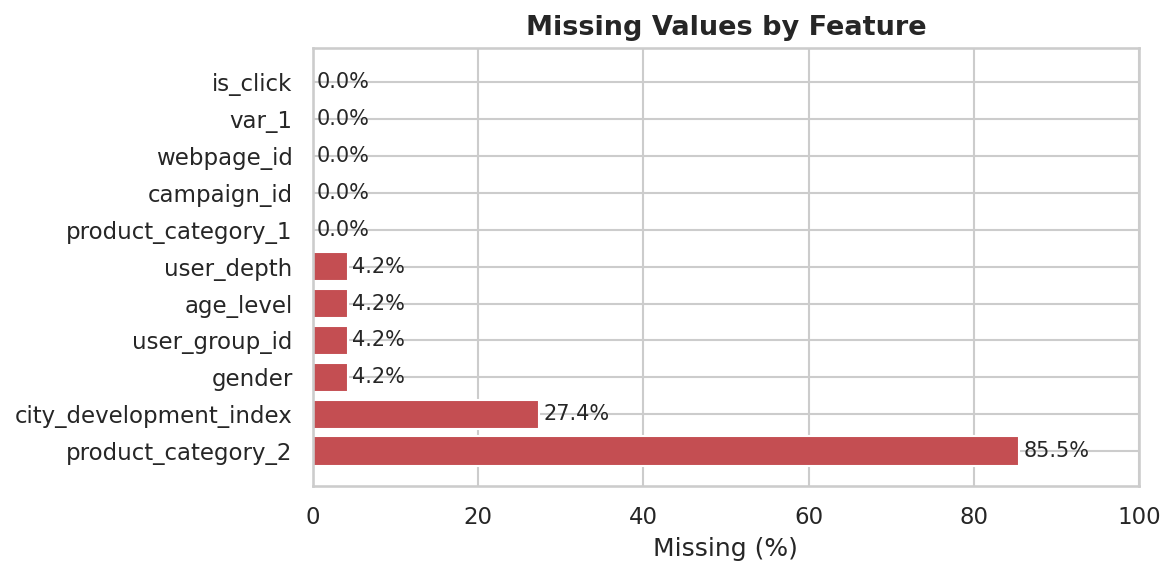

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color='#C44E52', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature', fontsize=13, fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('fig2_missing_values.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Combined missing values: Ad Click + Netflix datasets ──────────────
# Load Netflix here for comparison — no other dependencies needed
df_netflix_miss = pd.read_csv('netflix_titles.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Values — Ad Click vs Netflix Datasets', fontsize=14, fontweight='bold')

for ax, df_m, title in zip(
    axes,
    [df, df_netflix_miss],
    ['Ad Click CTR (463K rows)', 'Netflix Titles (8,807 rows)']
):
    missing = (df_m.isnull().sum() / len(df_m) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    if len(missing) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                fontsize=13, transform=ax.transAxes)
    else:
        colors = ['#C44E52' if v > 20 else '#4C72B0' for v in missing.values]
        bars = ax.barh(missing.index, missing.values, color=colors, edgecolor='white')
        ax.set_xlabel('Missing (%)')
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        for bar, val in zip(bars, missing.values):
            ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_missing_combined.png', bbox_inches='tight')
plt.show()
print('Note: AVA dataset has no missing values — vote counts present for all 255,530 images')


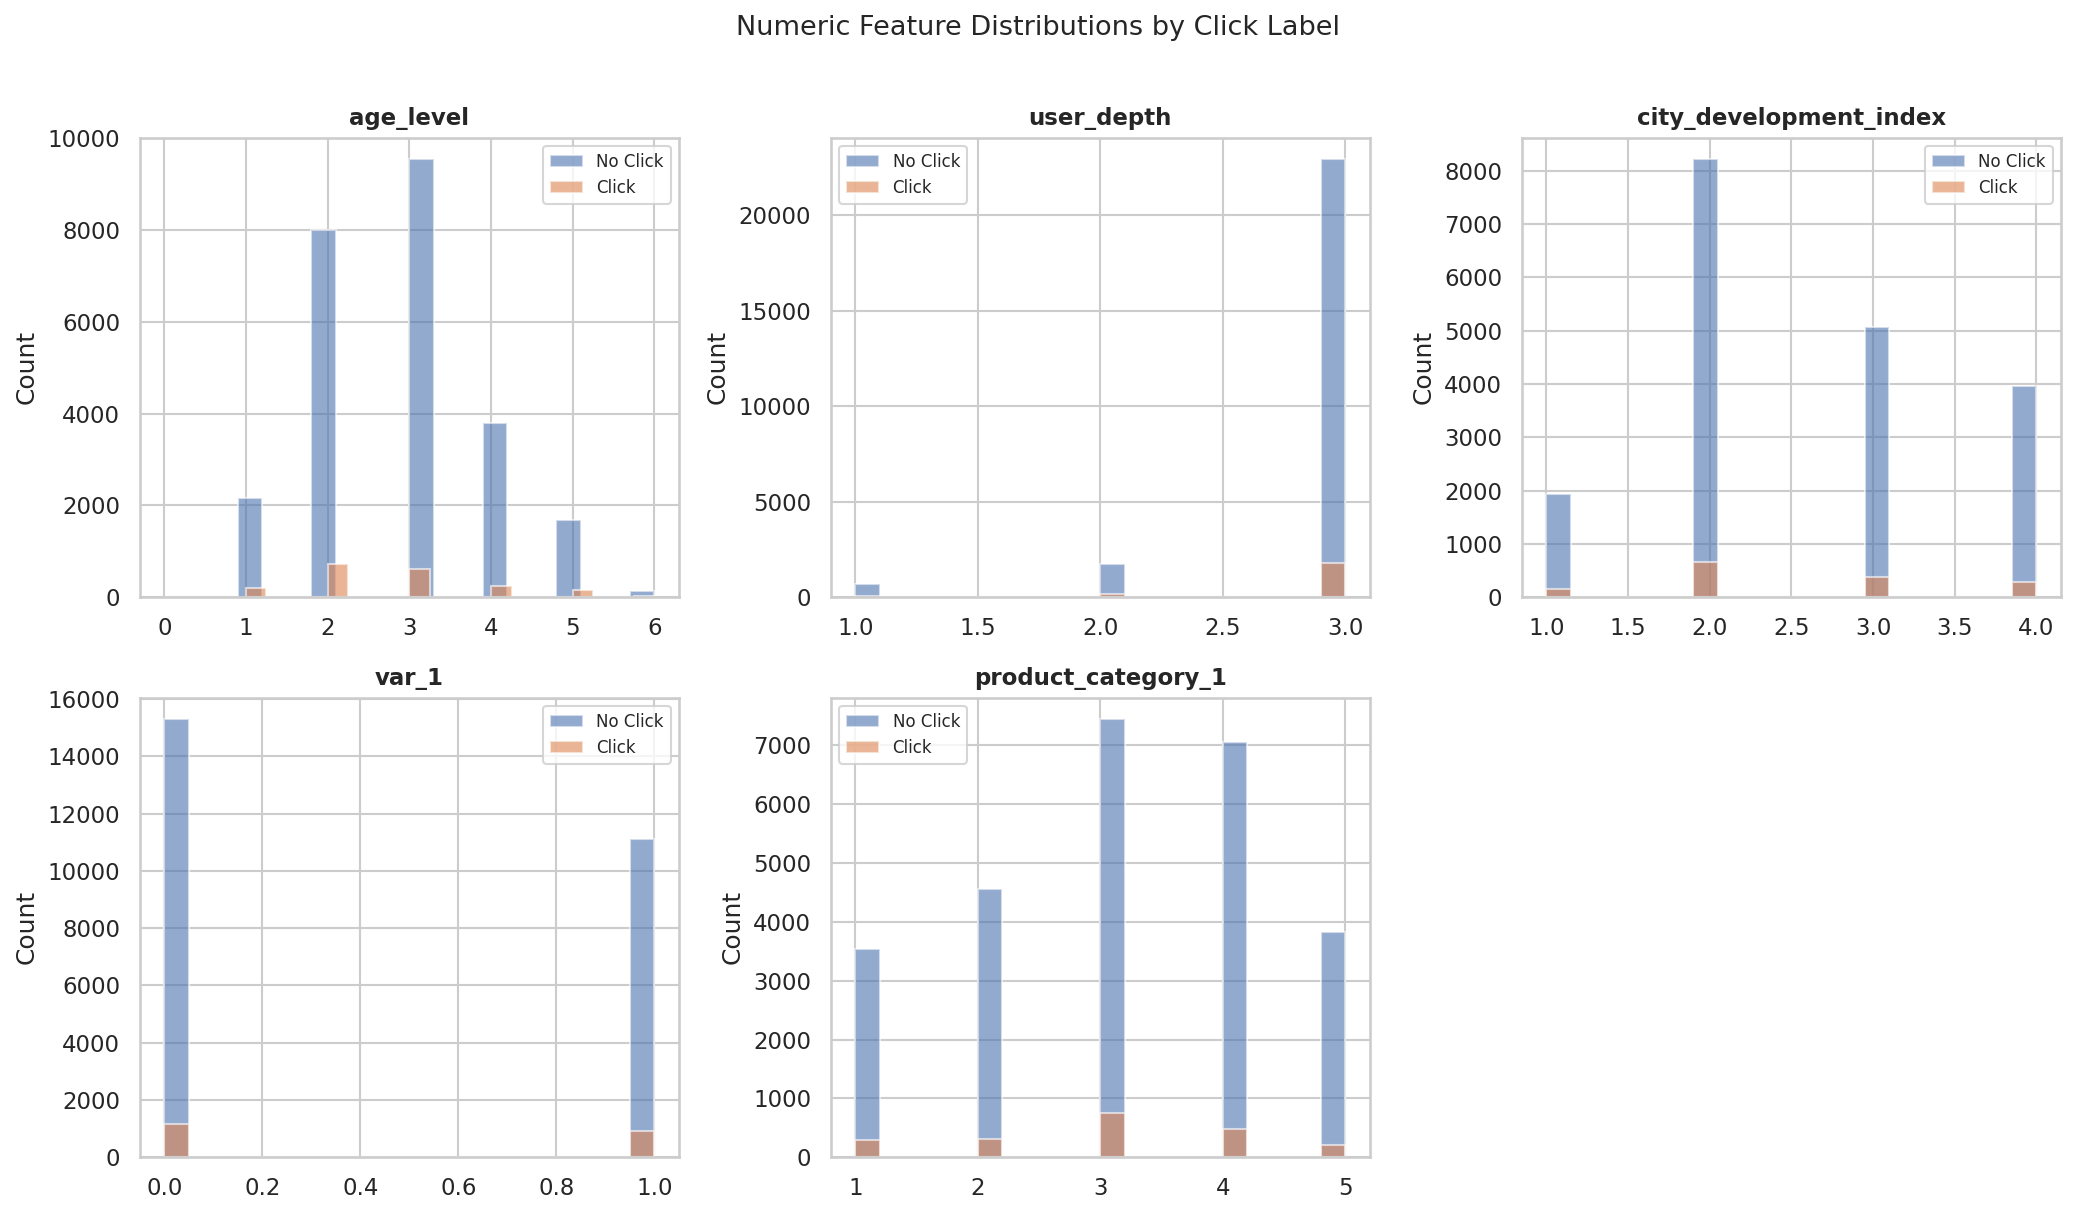

In [7]:
num_cols = ['age_level', 'user_depth', 'city_development_index', 'var_1', 'product_category_1']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = df[df['is_click'] == label][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                     label=f'{"Click" if label else "No Click"}', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Click Label', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_feature_distributions.png', bbox_inches='tight')
plt.show()

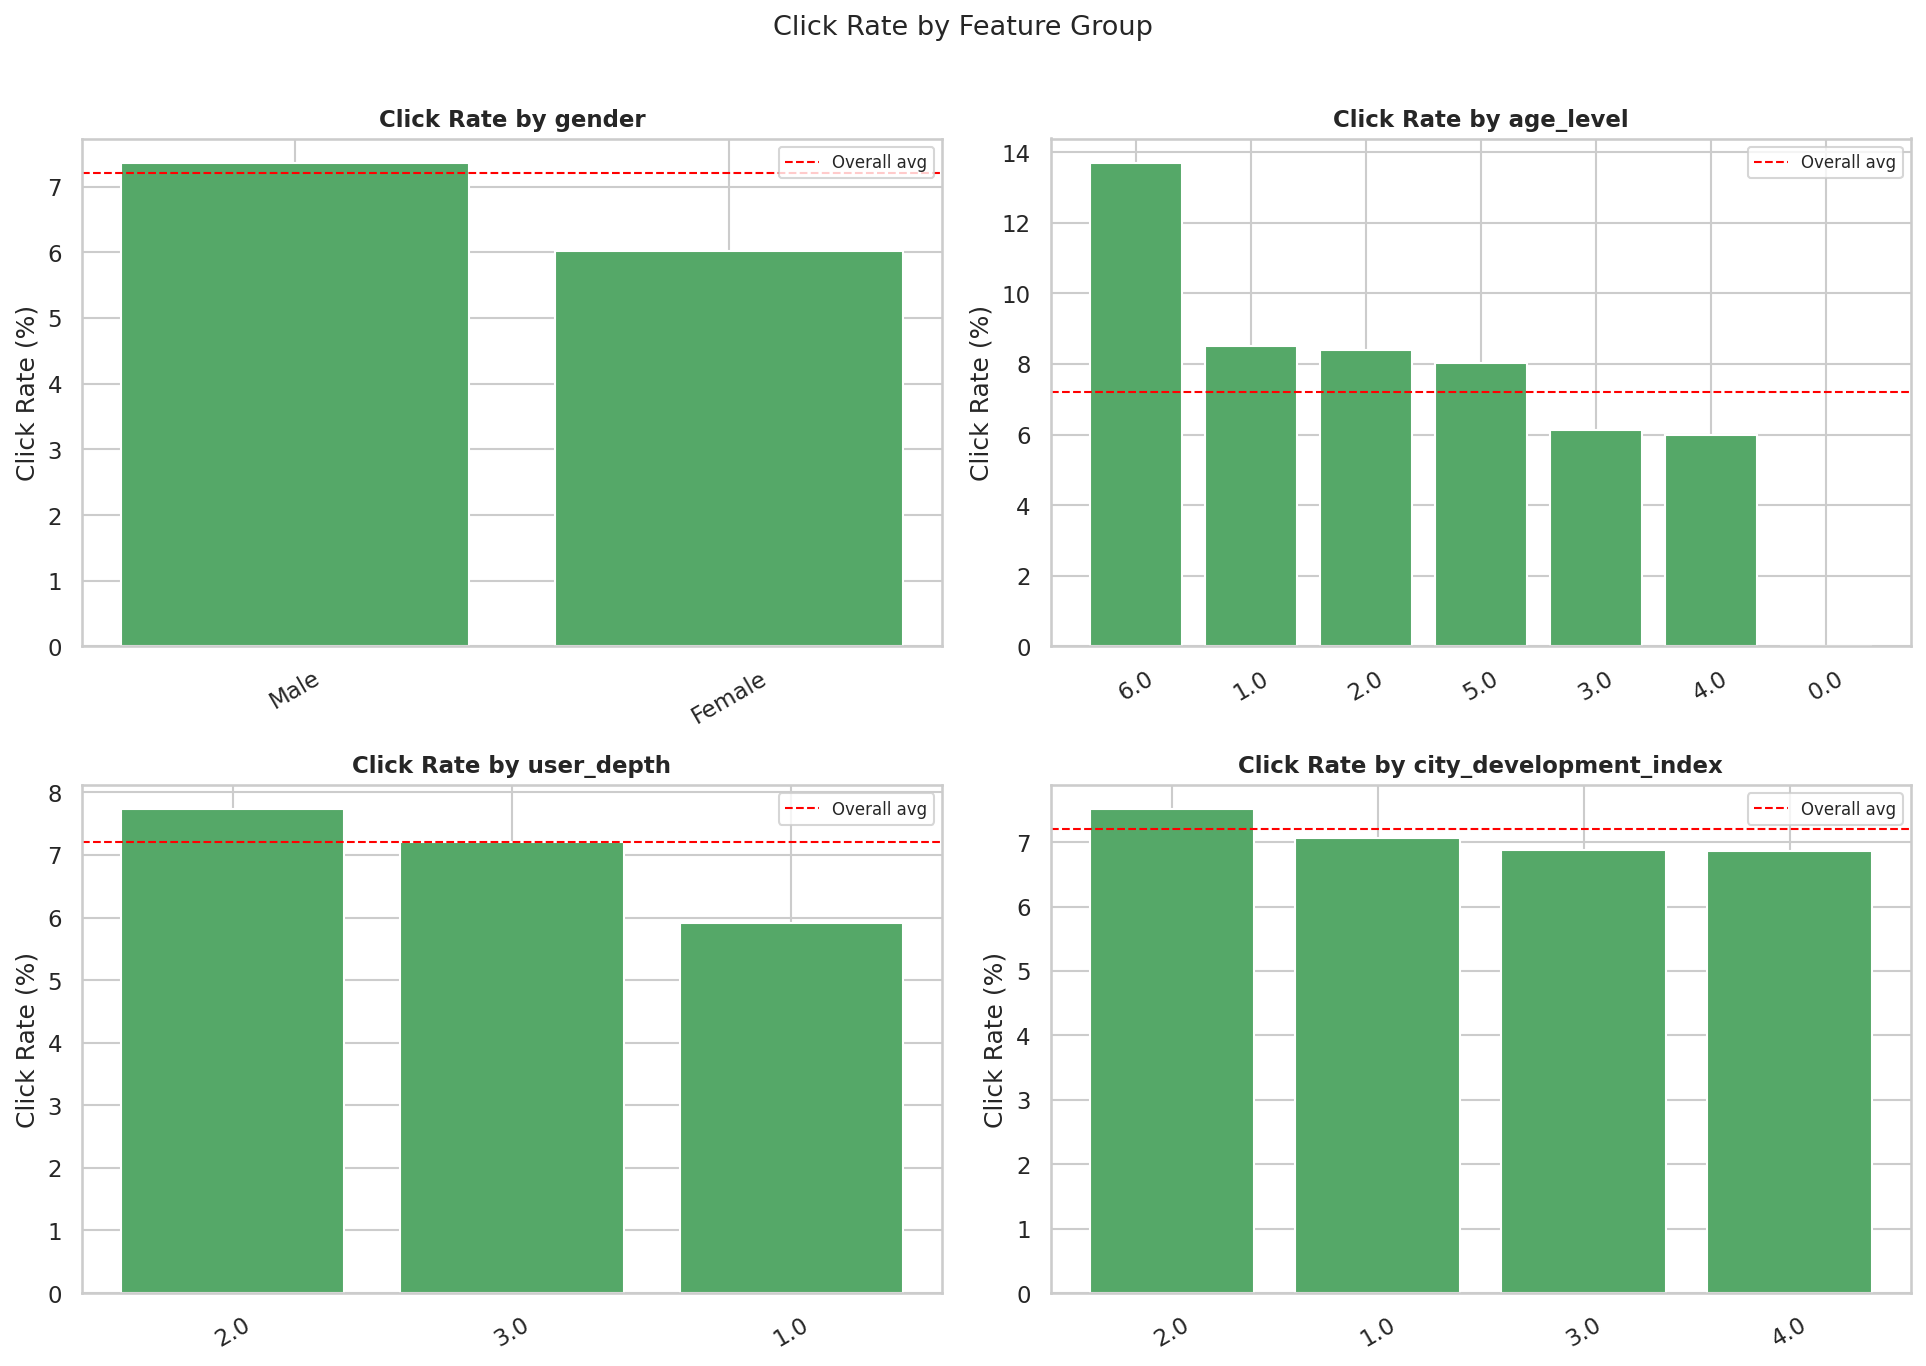

In [8]:
cat_features = ['gender', 'age_level', 'user_depth', 'city_development_index']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    cr = df.groupby(col)['is_click'].mean().sort_values(ascending=False)
    # Bin continuous cols for readability
    if df[col].nunique() > 10:
        df[f'{col}_bin'] = pd.qcut(df[col].fillna(df[col].median()), q=5, duplicates='drop')
        cr = df.groupby(f'{col}_bin')['is_click'].mean().sort_index()
        cr.index = cr.index.astype(str)

    axes[i].bar(cr.index.astype(str), cr.values * 100, color='#55A868', edgecolor='white')
    axes[i].set_title(f'Click Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Click Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['is_click'].mean()*100, color='red', linestyle='--', linewidth=1, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Click Rate by Feature Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig4_click_rates_by_feature.png', bbox_inches='tight')
plt.show()

In [10]:
import time

# Preprocessing
df_model = df.drop(columns=['session_id', 'DateTime', 'user_id', 'product_category_2'])
df_model['user_group_id'] = df_model['user_group_id'].fillna(-1)
df_model['gender'] = df_model['gender'].fillna('Unknown')
for col in ['age_level', 'user_depth', 'city_development_index']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

le = LabelEncoder()
for col in ['product', 'campaign_id', 'webpage_id', 'gender']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Interaction features
df_model['age_depth'] = df_model['age_level'] * df_model['user_depth']
df_model['city_var'] = df_model['city_development_index'] * df_model['var_1']

# Drop rows where target is missing
df_model = df_model.dropna(subset=['is_click'])
df_model['is_click'] = df_model['is_click'].astype(int)

X = df_model.drop(columns=['is_click'])
y = df_model['is_click']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE on train only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")

# Logistic Regression
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_sm)
X_test_lr = scaler.transform(X_test)

t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_lr, y_train_sm)
lr_time = time.time() - t0

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_lr)[:, 1])
print(f"LR AUC: {lr_auc:.4f} | Train time: {lr_time:.1f}s")

# XGBoost
neg, pos = np.bincount(y_train_sm)
t0 = time.time()
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                     scale_pos_weight=neg/pos, use_label_encoder=False,
                     eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
xgb_time = time.time() - t0

xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"XGB AUC: {xgb_auc:.4f} | Train time: {xgb_time:.1f}s")

After SMOTE: {np.int64(0): np.int64(21139), np.int64(1): np.int64(21139)}
LR AUC: 0.5596 | Train time: 0.3s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:58:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB AUC: 0.5722 | Train time: 0.8s


In [11]:
# === Reload clean ===
df_model = pd.read_csv('Ad_click_prediction_train (1).csv')
df_model = df_model.dropna(subset=['is_click'])
df_model['is_click'] = df_model['is_click'].astype(int)

# Drop non-predictive columns
df_model = df_model.drop(columns=['session_id', 'DateTime', 'user_id', 'product_category_2'])

# Impute
df_model['user_group_id'] = df_model['user_group_id'].fillna(-1)
df_model['gender'] = df_model['gender'].fillna('Unknown')
for col in ['age_level', 'user_depth', 'city_development_index']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Encode
le = LabelEncoder()
for col in ['product', 'campaign_id', 'webpage_id', 'gender']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Interaction features
df_model['age_depth'] = df_model['age_level'] * df_model['user_depth']
df_model['city_var'] = df_model['city_development_index'] * df_model['var_1']

print(f"Shape: {df_model.shape}, Click rate: {df_model['is_click'].mean()*100:.2f}%")
# Should show ~463K rows and ~6.8% click rate

X = df_model.drop(columns=['is_click'])
y = df_model['is_click']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE on train only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")
# Should show ~345K per class

# Logistic Regression
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_sm)
X_test_lr = scaler.transform(X_test)

t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_lr, y_train_sm)
lr_time = time.time() - t0
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_lr)[:, 1])
print(f"LR AUC: {lr_auc:.4f} | Train time: {lr_time:.1f}s")

# XGBoost
neg, pos = np.bincount(y_train_sm)
t0 = time.time()
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                     scale_pos_weight=neg/pos,
                     eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
xgb_time = time.time() - t0
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"XGB AUC: {xgb_auc:.4f} | Train time: {xgb_time:.1f}s")

Shape: (463291, 13), Click rate: 6.76%
After SMOTE: {np.int64(0): np.int64(345567), np.int64(1): np.int64(345567)}
LR AUC: 0.5571 | Train time: 2.9s
XGB AUC: 0.5753 | Train time: 10.7s


In [ ]:
# ── Correlation heatmap — Ad Click features incl. engineered ──────────
# Uses df_model which has age_depth and city_var added in cell above
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
corr = df_model[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix — Ad Click Features (incl. engineered)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print strongest correlations
corr_pairs = (
    corr.where(~mask)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .sort_values('correlation', key=abs, ascending=False)
)
print('Top 10 feature correlations:')
print(corr_pairs.head(10).to_string(index=False))


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train click rate: {y_train.mean()*100:.2f}%")

# Logistic Regression — class_weight handles imbalance
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
lr_time = time.time() - t0
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1])
print(f"LR AUC: {lr_auc:.4f} | Train time: {lr_time:.1f}s")

# XGBoost — scale_pos_weight handles imbalance natively
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}")

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_time = time.time() - t0
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"XGB AUC: {xgb_auc:.4f} | Train time: {xgb_time:.1f}s")

Train: (370632, 12), Test: (92659, 12)
Train click rate: 6.76%
LR AUC: 0.5573 | Train time: 2.0s
scale_pos_weight: 13.79
XGB AUC: 0.5814 | Train time: 14.4s


In [13]:
# Target encode high-cardinality categoricals on train fold only (no leakage)
high_card = ['product', 'campaign_id', 'webpage_id']

# Compute encoding from train set only
target_means = {}
X_train2 = X_train.copy()
X_test2 = X_test.copy()

for col in high_card:
    means = X_train[col].map(y_train.groupby(X_train[col]).mean())
    global_mean = y_train.mean()
    target_means[col] = y_train.groupby(X_train[col]).mean()
    X_train2[col] = means.fillna(global_mean)
    X_test2[col] = X_test[col].map(target_means[col]).fillna(global_mean)

print("Target encoding done.")
print(X_train2.head(2))

# Retrain XGBoost on target-encoded data
t0 = time.time()
xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg/pos,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb2.fit(X_train2, y_train)
xgb2_time = time.time() - t0
xgb2_auc = roc_auc_score(y_test, xgb2.predict_proba(X_test2)[:, 1])
print(f"XGB (target encoded) AUC: {xgb2_auc:.4f} | Train time: {xgb2_time:.1f}s")

# Also retrain LR on target-encoded + scaled data
scaler2 = StandardScaler()
X_train_sc2 = scaler2.fit_transform(X_train2)
X_test_sc2 = scaler2.transform(X_test2)
lr2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr2.fit(X_train_sc2, y_train)
lr2_auc = roc_auc_score(y_test, lr2.predict_proba(X_test_sc2)[:, 1])
print(f"LR  (target encoded) AUC: {lr2_auc:.4f}")

Target encoding done.
         product  campaign_id  webpage_id  product_category_1  user_group_id  \
351608  0.063839     0.053000    0.053000                   4            3.0   
205770  0.070190     0.058149    0.054126                   3            3.0   

        gender  age_level  user_depth  city_development_index  var_1  \
351608       1        3.0         3.0                     3.0      0   
205770       1        3.0         3.0                     3.0      1   

        age_depth  city_var  
351608        9.0       0.0  
205770        9.0       3.0  
XGB (target encoded) AUC: 0.5814 | Train time: 13.7s
LR  (target encoded) AUC: 0.5724


In [14]:
# Re-extract datetime features from raw
df_dt = pd.read_csv('Ad_click_prediction_train (1).csv', usecols=['DateTime', 'is_click'])
df_dt = df_dt.dropna(subset=['is_click'])
df_dt['hour'] = pd.to_datetime(df_dt['DateTime']).dt.hour
df_dt['dayofweek'] = pd.to_datetime(df_dt['DateTime']).dt.dayofweek

print(df_dt.groupby('hour')['is_click'].mean().round(3))
print(df_dt.groupby('dayofweek')['is_click'].mean().round(3))

hour
0     0.068
1     0.075
2     0.053
3     0.062
4     0.057
5     0.067
6     0.073
7     0.074
8     0.070
9     0.070
10    0.068
11    0.070
12    0.069
13    0.066
14    0.065
15    0.064
16    0.067
17    0.066
18    0.066
19    0.067
20    0.066
21    0.070
22    0.067
23    0.064
Name: is_click, dtype: float64
dayofweek
0    0.075
1    0.073
2    0.061
3    0.062
4    0.062
6    0.073
Name: is_click, dtype: float64


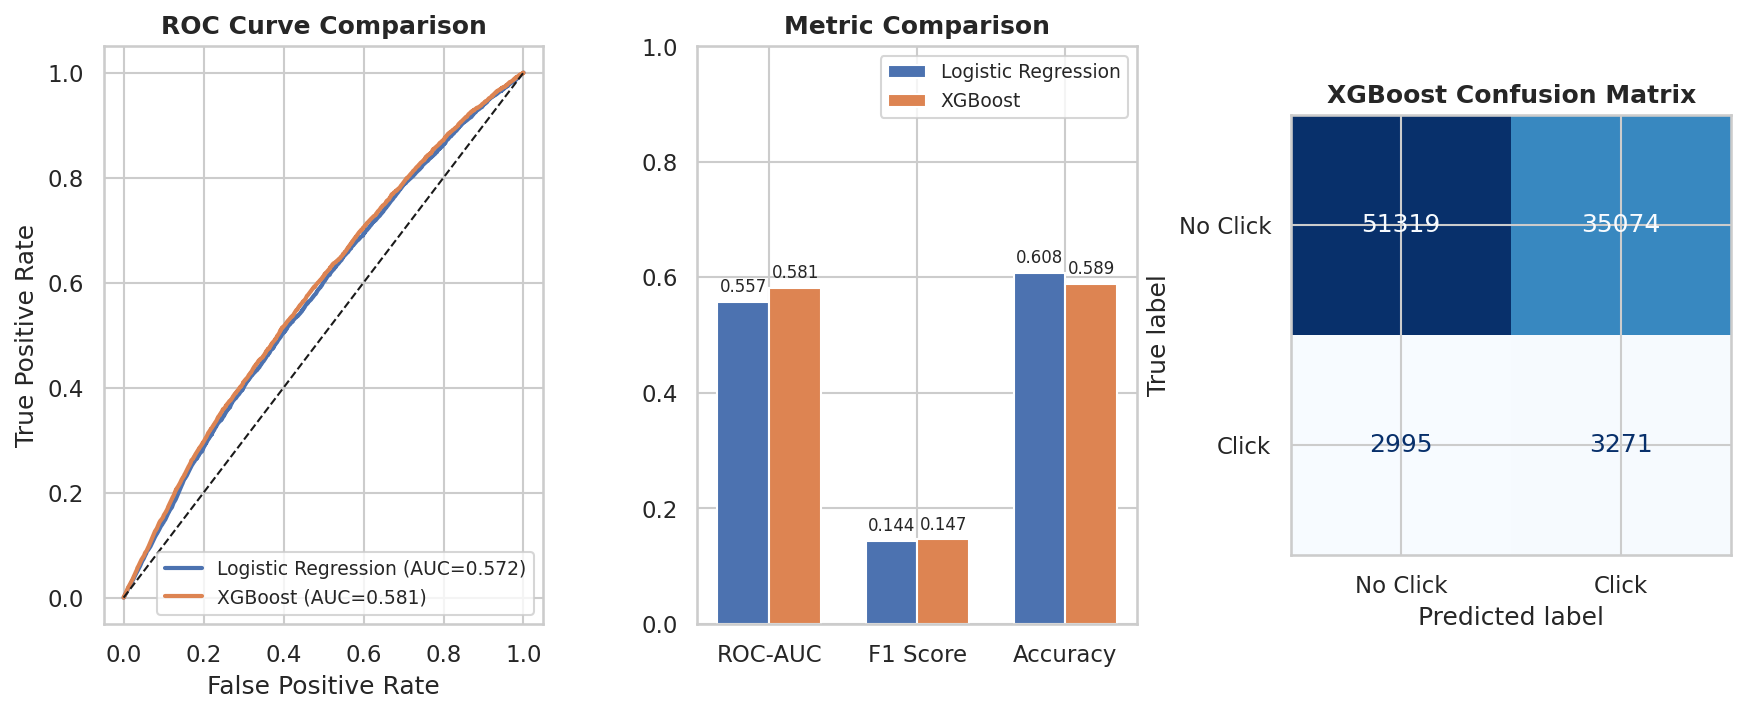


=== Model Summary ===
Model                       AUC       F1   Accuracy
--------------------------------------------------
Logistic Regression      0.5573   0.1436     0.6081
XGBoost                  0.5814   0.1466     0.5891


In [17]:
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- ROC curves ---
ax1 = fig.add_subplot(gs[0])
for model, name, X_t, color in [
    (lr2, 'Logistic Regression', X_test_sc2, '#4C72B0'),
    (xgb2, 'XGBoost', X_test2, '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_t)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:, 1])
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax1.plot([0,1],[0,1],'k--', lw=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison', fontweight='bold')
ax1.legend(fontsize=9)

# --- Metric bar chart ---
ax2 = fig.add_subplot(gs[1])
metrics = {
    'ROC-AUC': [lr_auc, xgb_auc],
}

from sklearn.metrics import f1_score, accuracy_score
lr_pred = lr2.predict(X_test_sc2)
xgb_pred = xgb2.predict(X_test2)
metrics['F1 Score'] = [f1_score(y_test, lr_pred), f1_score(y_test, xgb_pred)]
metrics['Accuracy'] = [accuracy_score(y_test, lr_pred), accuracy_score(y_test, xgb_pred)]

x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, [v[0] for v in metrics.values()], width, label='Logistic Regression', color='#4C72B0')
ax2.bar(x + width/2, [v[1] for v in metrics.values()], width, label='XGBoost', color='#DD8452')
ax2.set_xticks(x)
ax2.set_xticklabels(list(metrics.keys()))
ax2.set_ylim(0, 1)
ax2.set_title('Metric Comparison', fontweight='bold')
ax2.legend(fontsize=9)
for rect in ax2.patches:
    ax2.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
             f'{rect.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# --- XGBoost confusion matrix ---
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Click', 'Click'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title('XGBoost Confusion Matrix', fontweight='bold')

plt.savefig('fig5_model_results.png', bbox_inches='tight')
plt.show()

# Print summary table
print("\n=== Model Summary ===")
print(f"{'Model':<22} {'AUC':>8} {'F1':>8} {'Accuracy':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<22} {lr_auc:>8.4f} {f1_score(y_test, lr_pred):>8.4f} {accuracy_score(y_test, lr_pred):>10.4f}")
print(f"{'XGBoost':<22} {xgb_auc:>8.4f} {f1_score(y_test, xgb_pred):>8.4f} {accuracy_score(y_test, xgb_pred):>10.4f}")

In [ ]:
# ── Click rate by hour and day of week ────────────────────────────────
df_dt = df_raw.copy()
df_dt = df_dt.dropna(subset=['is_click'])
df_dt['hour'] = pd.to_datetime(df_dt['DateTime']).dt.hour
df_dt['dayofweek'] = pd.to_datetime(df_dt['DateTime']).dt.dayofweek
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day
hour_cr = df_dt.groupby('hour')['is_click'].mean() * 100
axes[0].plot(hour_cr.index, hour_cr.values, marker='o', color='#4C72B0', linewidth=2)
axes[0].fill_between(hour_cr.index, hour_cr.values, alpha=0.15, color='#4C72B0')
axes[0].axhline(y=df_dt['is_click'].mean()*100, color='red',
                linestyle='--', linewidth=1, label='Overall avg')
axes[0].set_title('Click Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Click Rate (%)')
axes[0].legend(fontsize=9)

# Day of week
day_cr = df_dt.groupby('dayofweek')['is_click'].mean() * 100
axes[1].bar(
    [day_labels[d] for d in day_cr.index],
    day_cr.values,
    color='#55A868', edgecolor='white'
)
axes[1].axhline(y=df_dt['is_click'].mean()*100, color='red',
                linestyle='--', linewidth=1, label='Overall avg')
axes[1].set_title('Click Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Click Rate (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Temporal Patterns — No strong signal found', fontsize=12, style='italic', y=1.01)
plt.tight_layout()
plt.savefig('fig_temporal_patterns.png', bbox_inches='tight')
plt.show()
print('Finding: click rate is flat across hours (5.3-7.5%) and days — temporal features excluded from model')


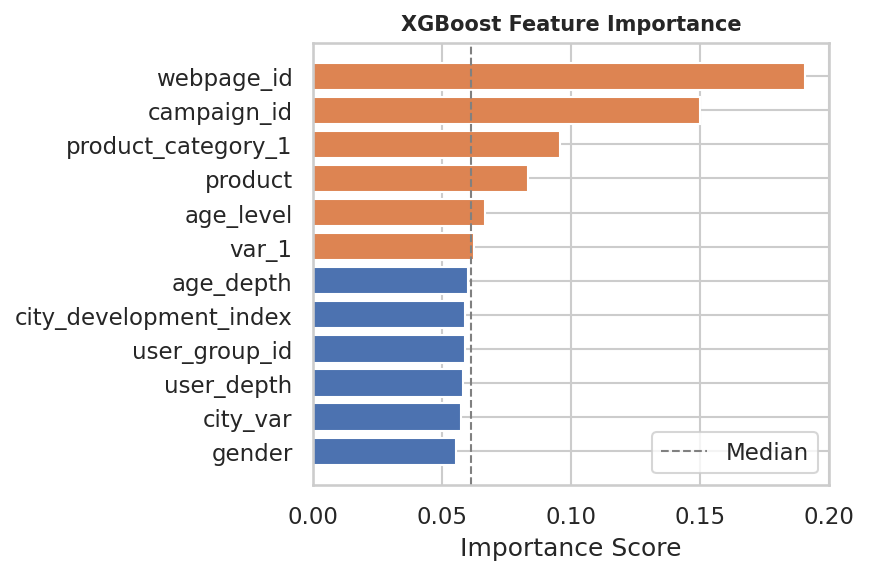

In [26]:
feat_imp = pd.Series(xgb2.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#DD8452' if v > feat_imp.median() else '#4C72B0' for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=10, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=feat_imp.median(), color='gray', linestyle='--', linewidth=1, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', bbox_inches='tight')
plt.show()

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Build full target-encoded X for CV
X_te_full = X.copy()
global_mean = y.mean()
for col in ['product', 'campaign_id', 'webpage_id']:
    X_te_full[col] = X[col].map(y.groupby(X[col]).mean()).fillna(global_mean)

xgb_cv = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=13.79, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
cv_scores = cross_val_score(xgb_cv, X_te_full, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost 5-Fold CV ROC-AUC:")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

XGBoost 5-Fold CV ROC-AUC:
  Fold scores: ['0.5878', '0.5771', '0.5828', '0.5890', '0.5812']
  Mean: 0.5836  |  Std: 0.0044
